# Phase 8: Feature Importance Analysis and Model Interpretation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Step 1: Load Feature Importance Results

The following objects were generated during Phase 7 Predictive Modeling and will be used for feature interpretation:

- telco_feature_importance
- retail_feature_importance
- sales_feature_importance
- best_models_by_dataset
- model_results

If running Phase 8 independently, load the exported CSV files from the reports directory.

In [2]:
telco_feature_importance = pd.read_csv(
    "../reports/telco_feature_importance.csv"
)

retail_feature_importance = pd.read_csv(
    "../reports/retail_feature_importance.csv"
)

sales_feature_importance = pd.read_csv(
    "../reports/sales_feature_importance.csv"
)

best_models_by_dataset = pd.read_csv(
    "../reports/best_models_by_dataset.csv"
)

model_results = pd.read_csv(
    "../reports/model_comparison.csv"
)

## Step 2: Visualize Telco Feature Importance

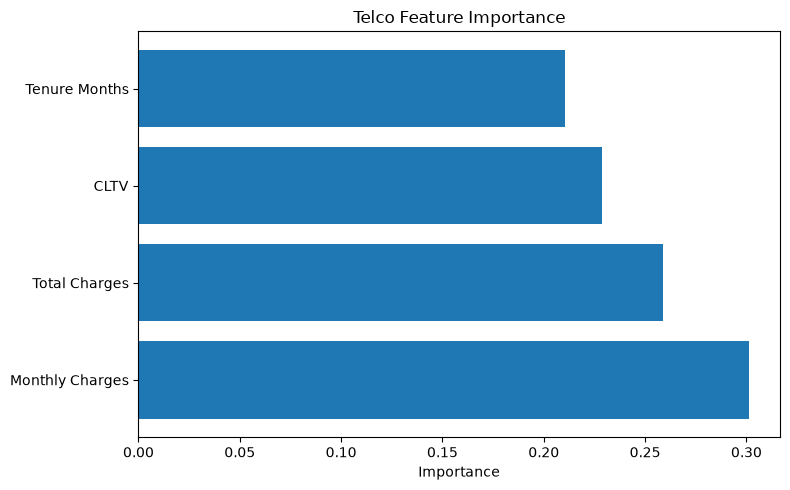

In [3]:
plt.figure(figsize=(8, 5))

plt.barh(
    telco_feature_importance["Feature"],
    telco_feature_importance["Importance"]
)

plt.title(
    "Telco Feature Importance"
)

plt.xlabel(
    "Importance"
)

plt.tight_layout()

plt.savefig(
    "../reports/telco_feature_importance.png"
)

plt.show()

## Step 3: Visualize Retail Churn Feature Importance

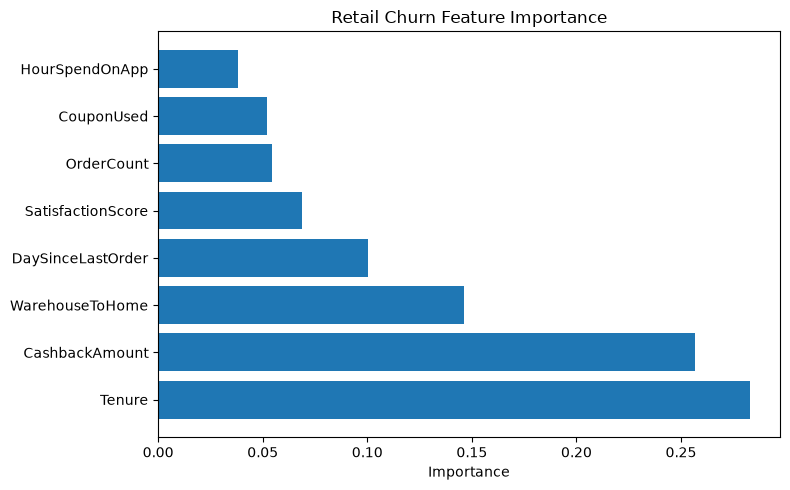

In [4]:
plt.figure(figsize=(8, 5))

plt.barh(
    retail_feature_importance["Feature"],
    retail_feature_importance["Importance"]
)

plt.title(
    "Retail Churn Feature Importance"
)

plt.xlabel(
    "Importance"
)

plt.tight_layout()

plt.savefig(
    "../reports/retail_churn_feature_importance.png"
)

plt.show()

## Step 4: Visualize Retail Sales Feature Importance

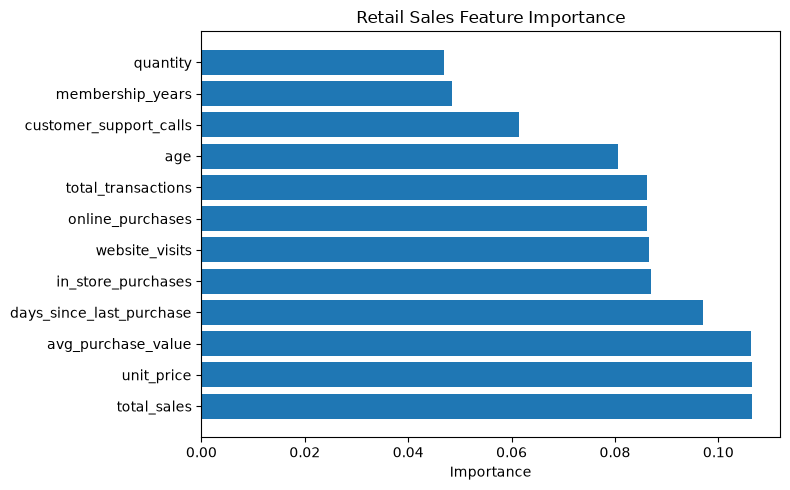

In [5]:
plt.figure(figsize=(8, 5))

plt.barh(
    sales_feature_importance["Feature"],
    sales_feature_importance["Importance"]
)

plt.title(
    "Retail Sales Feature Importance"
)

plt.xlabel(
    "Importance"
)

plt.tight_layout()

plt.savefig(
    "../reports/retail_sales_feature_importance.png"
)

plt.show()

## Step 5: Identify Top Features

### Telco

In [6]:
top_telco = (
    telco_feature_importance
    .head(3)
    .reset_index(drop=True)
)

top_telco

,Feature,Importance
0,Monthly Charges,0.301485
1,Total Charges,0.259010
2,CLTV,0.228862


### Retail Churn

In [7]:
top_retail = (
    retail_feature_importance
    .head(3)
    .reset_index(drop=True)
)

top_retail

,Feature,Importance
0,Tenure,0.283169
1,CashbackAmount,0.256894
2,WarehouseToHome,0.146088


### Retail Sales

In [8]:
top_sales = (
    sales_feature_importance
    .head(3)
    .reset_index(drop=True)
)

top_sales

,Feature,Importance
0,total_sales,0.106597
1,unit_price,0.106566
2,avg_purchase_value,0.106384


## Step 6: Convert Features into Business Insights

### Telco Example

In [9]:
telco_insights = {
    "Tenure Months":
        "Newer customers are more likely to churn.",

    "Monthly Charges":
        "Customers with higher monthly costs may be more likely to leave.",

    "Total Charges":
        "Overall spending influences retention.",

    "CLTV":
        "Customer lifetime value is associated with churn behavior."
}

### Retail Churn Example

In [10]:
retail_insights = {
    "DaySinceLastOrder":
        "Customers who stop purchasing become more likely to churn.",

    "CashbackAmount":
        "Rewards and incentives influence retention.",

    "OrderCount":
        "Frequent buyers are less likely to churn.",

    "SatisfactionScore":
        "Customer satisfaction strongly impacts loyalty."
}

### Retail Sales Example

In [11]:
sales_insights = {
    "customer_support_calls":
        "Customer service interactions may indicate customer frustration.",

    "days_since_last_purchase":
        "Long purchasing gaps may indicate churn risk.",

    "total_sales":
        "Higher spending customers may behave differently from lower spending customers."
}

## Step 7: Compare Top Drivers Across Datasets

In [12]:
driver_comparison = pd.DataFrame({
    "Telco Feature":
        top_telco["Feature"],
    "Telco Importance":
        top_telco["Importance"].round(4),

    "Retail Churn Feature":
        top_retail["Feature"],
    "Retail Churn Importance":
        top_retail["Importance"].round(4),

    "Retail Sales Feature":
        top_sales["Feature"],
    "Retail Sales Importance":
        top_sales["Importance"].round(4)
})

driver_comparison.index = (
    driver_comparison.index + 1
)

driver_comparison.index.name = "Rank"

driver_comparison

,Telco Feature,Telco Importance,Retail Churn Feature,Retail Churn Importance,Retail Sales Feature,Retail Sales Importance
Rank,,,,,,
1,Monthly Charges,0.3015,Tenure,0.2832,total_sales,0.1066
2,Total Charges,0.2590,CashbackAmount,0.2569,unit_price,0.1066
3,CLTV,0.2289,WarehouseToHome,0.1461,avg_purchase_value,0.1064


In [13]:
# Export
driver_comparison.to_csv(
    "../reports/top_churn_drivers.csv",
    index=False
)

## Step 8: Generate Feature Importance Report

In [14]:
report_file = Path(
    "../reports/feature_importance_summary.md"
)

with open(
    report_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "# Feature Importance Analysis\n\n"
    )

    # ----------------------------------

    f.write(
        "## Telco Customer Churn\n\n"
    )

    f.write(
        telco_feature_importance
        .head(10)
        .round(4)
        .to_markdown(index=False)
    )

    f.write("\n\n")

    # ----------------------------------

    f.write(
        "## Retail Customer Churn\n\n"
    )

    f.write(
        retail_feature_importance
        .head(10)
        .round(4)
        .to_markdown(index=False)
    )

    f.write("\n\n")

    # ----------------------------------

    f.write(
        "## Retail Sales\n\n"
    )

    f.write(
        sales_feature_importance
        .head(10)
        .round(4)
        .to_markdown(index=False)
    )

    f.write("\n\n")

    # ----------------------------------

    f.write(
        "## Cross-Dataset Comparison\n\n"
    )

    f.write(
        driver_comparison
        .to_markdown(index=False)
    )

print(
    f"Created: {report_file}"
)

Created: ..\reports\feature_importance_summary.md


## Step 9: Generate Dynamic Business Recommendations

In [15]:
recommendation_map = {

    # Telco
    "Tenure Months":
        "Develop onboarding and retention programs targeting newer customers.",

    "Monthly Charges":
        "Review pricing strategies and offer discounts to high-cost customers.",

    "Total Charges":
        "Analyze customer spending patterns and develop targeted retention programs based on lifetime customer value.",
    
    "CLTV":
        "Use customer lifetime value segmentation to prioritize retention initiatives and allocate marketing resources efficiently.",
    
    # Retail Churn
    "Tenure":
        "Build retention programs focused on recently acquired customers.",

    "CashbackAmount":
        "Expand reward and cashback programs to improve retention.",

    "DaySinceLastOrder":
        "Implement re-engagement campaigns for inactive customers.",

    "OrderCount":
        "Encourage repeat purchases through loyalty incentives and personalized marketing.",

    "SatisfactionScore":
        "Improve customer experience initiatives to increase customer satisfaction.",

    "CouponUsed":
        "Target customers with personalized discounts and promotional offers.",

    "WarehouseToHome":
        "Evaluate delivery distance impacts and improve logistics, fulfillment speed, or local distribution options.",

    # Retail Sales
    "total_sales":
        "Develop VIP retention programs for high-spending customers.",

    "unit_price":
        "Review pricing competitiveness and identify customer segments that are sensitive to product pricing.",

    "avg_purchase_value":
        "Increase customer value through targeted bundle offers and cross-selling initiatives.",

    "customer_support_calls":
        "Investigate service issues and improve customer support quality.",

    "days_since_last_purchase":
        "Identify inactive customers and launch proactive win-back campaigns.",

    "customer_value_score":
        "Focus retention resources on high-value customers.",

    "return_rate":
        "Investigate return behavior and potential customer dissatisfaction issues.",

    "online_purchase_ratio":
        "Enhance online shopping experiences and digital engagement strategies.",

    "sales_per_transaction":
        "Encourage larger basket sizes through upselling and cross-selling."
}

### Identify Top 3 Features Per Dataset

In [16]:
top_telco_feature = (
    telco_feature_importance
    .iloc[0]["Feature"]
)

top_retail_feature = (
    retail_feature_importance
    .iloc[0]["Feature"]
)

top_sales_feature = (
    sales_feature_importance
    .iloc[0]["Feature"]
)

### Generate Recommendations Report

In [17]:
report_file = Path(
    "../reports/business_recommendations.md"
)

with open(
    report_file,
    "w",
    encoding="utf-8"
) as f:

    f.write("# Business Recommendations\n\n")

    # ==================================================
    # TELCO
    # ==================================================

    telco_top3 = (
        telco_feature_importance
        .head(3)
        .reset_index(drop=True)
    )

    f.write("## Telco Customer Churn\n\n")

    f.write("### Top Churn Drivers\n\n")

    f.write(
        telco_top3
        .round(4)
        .to_markdown(index=False)
    )

    f.write("\n\n")

    f.write("### Interpretation\n\n")

    telco_features = (
        telco_top3["Feature"]
        .tolist()
    )

    f.write(
        f"The Random Forest model identified "
        f"**{telco_features[0]}**, "
        f"**{telco_features[1]}**, and "
        f"**{telco_features[2]}** as the strongest predictors of churn. "
        f"This suggests pricing and customer value are major drivers of customer retention.\n\n"
    )

    f.write("### Recommendations\n\n")

    for feature in telco_features:

        f.write(
            f"- **{feature}**: "
            f"{recommendation_map.get(feature)}\n"
        )

    f.write("\n")

    # ==================================================
    # RETAIL CHURN
    # ==================================================

    retail_top3 = (
        retail_feature_importance
        .head(3)
        .reset_index(drop=True)
    )

    f.write("## Retail Customer Churn\n\n")

    f.write("### Top Churn Drivers\n\n")

    f.write(
        retail_top3
        .round(4)
        .to_markdown(index=False)
    )

    f.write("\n\n")

    retail_features = (
        retail_top3["Feature"]
        .tolist()
    )

    f.write("### Interpretation\n\n")

    f.write(
        f"The Random Forest model identified "
        f"**{retail_features[0]}**, "
        f"**{retail_features[1]}**, and "
        f"**{retail_features[2]}** as the strongest churn indicators. "
        f"Customer tenure, incentives, and service accessibility appear to influence customer retention decisions.\n\n"
    )

    f.write("### Recommendations\n\n")

    for feature in retail_features:

        f.write(
            f"- **{feature}**: "
            f"{recommendation_map.get(feature)}\n"
        )

    f.write("\n")

    # ==================================================
    # RETAIL SALES
    # ==================================================

    sales_top3 = (
        sales_feature_importance
        .head(3)
        .reset_index(drop=True)
    )

    f.write("## Retail Sales\n\n")

    f.write("### Top Churn Drivers\n\n")

    f.write(
        sales_top3
        .round(4)
        .to_markdown(index=False)
    )

    f.write("\n\n")

    sales_features = (
        sales_top3["Feature"]
        .tolist()
    )

    f.write("### Interpretation\n\n")

    f.write(
        f"The Random Forest model identified "
        f"**{sales_features[0]}**, "
        f"**{sales_features[1]}**, and "
        f"**{sales_features[2]}** as the most important predictors. "
        f"These variables relate primarily to customer spending behavior and purchasing value.\n\n"
    )

    f.write("### Recommendations\n\n")

    for feature in sales_features:

        f.write(
            f"- **{feature}**: "
            f"{recommendation_map.get(feature)}\n"
        )

    f.write("\n")

    # ==================================================
    # RETAIL SALES MODEL PERFORMANCE
    # ==================================================

    retail_sales_best = (
        best_models_by_dataset[
            best_models_by_dataset["Dataset"]
            == "Retail Sales"
        ]
        .iloc[0]
    )

    f.write("### Model Performance\n\n")

    f.write(
        f"- Best Model: {retail_sales_best['Model']}\n"
    )
    
    f.write(
        f"- Accuracy: {retail_sales_best['Accuracy']:.4f}\n"
    )
    
    f.write(
        f"- F1 Score: {retail_sales_best['F1']:.4f}\n\n"
    )

    # ==================================================
    # RETAIL SALES LIMITATION
    # ==================================================

    if retail_sales_best["F1"] < 0.60:

        f.write(
            "### Retail Sales Modeling Limitation\n\n"
        )

        f.write(
            f"The best Retail Sales model achieved an F1 score of "
            f"{retail_sales_best['F1']:.4f}, indicating limited predictive performance.\n\n"
        )
        
        f.write(
            "The Retail Sales dataset performed substantially worse than the "
            "Telco and Retail Customer Churn datasets (F1 ≈ 0.81), suggesting "
            "that the currently selected feature set provides limited predictive "
            "information regarding churn.\n\n"
        )
        
        f.write(
            "Although the identified features were the most important within the model, "
            "the overall predictive capability remains relatively weak. "
            "These findings should therefore be interpreted cautiously.\n\n"
        )

        f.write(
            "Future work should investigate:\n\n"
        )

        f.write(
            "- Loyalty program participation\n"
        )

        f.write(
            "- Purchase frequency variables\n"
        )

        f.write(
            "- Promotion effectiveness metrics\n"
        )

        f.write(
            "- Customer engagement indicators (app usage, email subscriptions, social media engagement)\n"
        )

        f.write(
            "- Additional behavioral feature engineering\n\n"
        )

    # ==================================================
    # CROSS-INDUSTRY INSIGHTS
    # ==================================================

    f.write(
        "## Cross-Industry Insights\n\n"
    )
    
    f.write(
        "- Telco churn appears to be heavily influenced by pricing and customer value metrics.\n"
    )
    
    f.write(
        "- Retail Customer Churn appears to be influenced by customer tenure, rewards programs, and service accessibility.\n"
    )
    
    f.write(
        "- Retail Sales exhibited weak predictive performance, indicating that additional behavioral and engagement variables may be required.\n"
    )
    
    f.write(
        "- Feature importance analysis provides actionable business intelligence for customer retention strategies.\n"
    )
    
    f.write(
        "- Organizations should continuously monitor the top churn drivers identified by predictive models and adapt retention initiatives accordingly.\n"
    )

    f.write(
        "- Telco and Retail Customer Churn models achieved strong predictive performance (F1 ≈ 0.81), indicating that customer churn can be predicted with reasonable accuracy using the selected features.\n"
    )

    # ==================================================
    # EXECUTIVE SUMMARY
    # ==================================================

    f.write(
        "## Executive Summary\n\n"
    )
    
    f.write(
        "- Monthly Charges emerged as the strongest predictor of churn in the Telco dataset.\n"
    )
    
    f.write(
        "- Customer Tenure was the strongest predictor of churn in the Retail Customer Churn dataset.\n"
    )
    
    f.write(
        "- Total Sales was identified as the most influential Retail Sales feature; however, the overall model performance was limited.\n"
    )
    
    f.write(
        "- Predictive modeling suggests that pricing, customer value, customer tenure, and customer incentives are the most important retention levers across the analyzed industries.\n"
    )
    
    f.write(
        "- Organizations can leverage these insights to improve customer retention strategies, prioritize high-risk customers, and deploy proactive intervention programs.\n"
    )

print(
    f"Created: {report_file}"
)

Created: ..\reports\business_recommendations.md


## Step 10: Add Model Interpretation Section

In [18]:
with open(
    "../reports/feature_importance_summary.md",
    "a",
    encoding="utf-8"
) as f:

    f.write(
        "\n\n## Model Interpretation\n\n"
    )

    f.write(
        "Feature importance analysis identified the customer characteristics most strongly associated with churn.\n\n"
    )

    f.write(
        "These findings provide a foundation for targeted retention strategies and proactive customer engagement programs.\n"
    )